In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv('placement.csv')

In [7]:
df.head()


,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [8]:
df.shape

(200, 2)

Text(0, 0.5, 'Package(in lpa)')

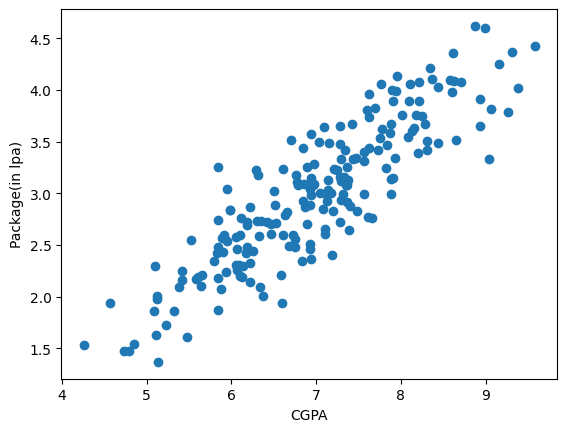

In [6]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [9]:
X = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [10]:
X.head()

,cgpa
0,6.89
1,5.12
2,7.82
3,7.42
4,6.94


In [11]:
y.head()

0    3.26
1    1.98
2    3.25
3    3.67
4    3.57
Name: package, dtype: float64

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [13]:
from sklearn.linear_model import LinearRegression

In [14]:
lr = LinearRegression()

In [15]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Text(0, 0.5, 'Package(in lpa)')

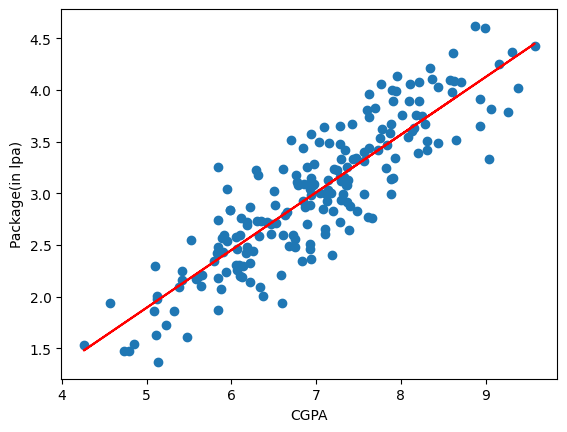

In [16]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [17]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [18]:
y_pred = lr.predict(X_test)

In [19]:
y_test.values

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

In [20]:
print("MAE",mean_absolute_error(y_test,y_pred))

MAE 0.2884710931878175


In [21]:
print("MSE",mean_squared_error(y_test,y_pred))

MSE 0.12129235313495527


In [22]:
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred)))

RMSE 0.34827051717731616


In [23]:
print("MSE",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

MSE 0.780730147510384


In [24]:
# Adjusted R2 score
X_test.shape

(40, 1)

In [25]:
1 - ((1-r2)*(40-1)/(40-1-1))

0.7749598882343415

In [26]:
new_df1 = df.copy()
new_df1['random_feature'] = np.random.random(200)

new_df1 = new_df1[['cgpa','random_feature','package']]
new_df1.head()

,cgpa,random_feature,package
0,6.89,0.508429,3.26
1,5.12,0.559331,1.98
2,7.82,0.422014,3.25
3,7.42,0.790069,3.67
4,6.94,0.122783,3.57


Text(0, 0.5, 'Package(in lpa)')

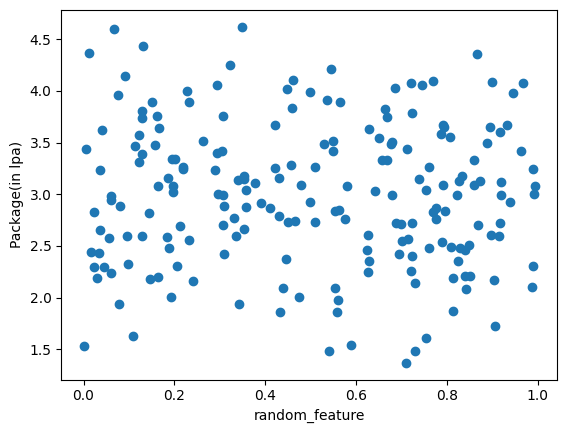

In [27]:
plt.scatter(new_df1['random_feature'],new_df1['package'])
plt.xlabel('random_feature')
plt.ylabel('Package(in lpa)')

In [50]:
X = new_df1.iloc[:,0:2]
y = new_df1.iloc[:,-1]

In [51]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [52]:
lr = LinearRegression()

In [53]:
lr.fit(X_train,y_train)

LinearRegression()

In [54]:
y_pred = lr.predict(X_test)

In [55]:
print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 score 0.781133851209665


In [56]:
1 - ((1-r2)*(40-1)/(40-1-2))

0.7693032485723497

In [148]:
new_df2 = df.copy()

new_df2['iq'] = new_df2['package'] + (np.random.randint(-12,12,200)/10)

new_df2 = new_df2[['cgpa','iq','package']]

In [149]:
new_df2.sample(5)

,cgpa,iq,package
42,5.95,2.44,2.54
180,6.19,1.52,2.72
38,8.62,5.06,4.36
23,6.19,2.38,2.48
98,7.69,3.83,3.83


Text(0, 0.5, 'Package(in lpa)')

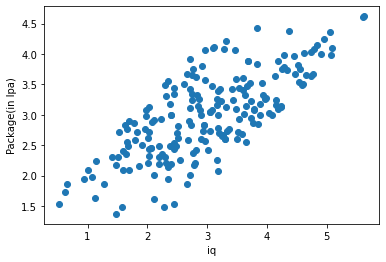

In [150]:
plt.scatter(new_df2['iq'],new_df2['package'])
plt.xlabel('iq')
plt.ylabel('Package(in lpa)')

In [126]:
np.random.randint(-100,100)

44

In [151]:
X = new_df2.iloc[:,0:2]
y = new_df2.iloc[:,-1]

In [152]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [154]:
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)

In [155]:
print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 score 0.8000928965773431


In [156]:
1 - ((1-r2)*(40-1)/(40-1-2))

0.7892871072031453

# Linear Regression Evaluation Metrics

## 1. R² Score (Coefficient of Determination)
**Formula:**  
R² = 1 − (SS_res / SS_tot)  
(Residual Sum of Squares): The sum of the squares of the differences between the actual and predicted values.  

(Total Sum of Squares): The sum of the squares of the differences between the actual values and their mean.  

**What it measures:**  
Proportion of variance in dependent variable explained by model.

**Advantages**
- Easy to interpret (0 to 1 scale).
- Good for comparing models with same dataset.
- Indicates overall fit quality.

**Disadvantages**
- Always increases when more features are added.
- Does not indicate model bias.
- Can be misleading for nonlinear relationships.

---

## 2. Adjusted R²
**Formula:**  
Adjusted R² = 1 − [(1 − R²)(n − 1) / (n − p − 1)]

Where  
n = samples  
p = predictors

**Advantages**
- Penalizes unnecessary features.
- Better metric for multiple regression.
- Helps detect overfitting.

**Disadvantages**
- Harder to interpret than R².
- Still not useful for nonlinear models.

---

## 3. Mean Absolute Error (MAE)
**Formula:**  
MAE = (1/n) Σ |yᵢ − ŷᵢ|

**Advantages**
- Easy to understand.
- Not sensitive to outliers.
- Same unit as target variable.

**Disadvantages**
- Does not penalize large errors strongly.
- Less sensitive to model performance changes.

---

## 4. Mean Squared Error (MSE)
**Formula:**  
MSE = (1/n) Σ (yᵢ − ŷᵢ)²

**Advantages**
- Penalizes large errors heavily.
- Differentiable so useful for optimization.
- Widely used in training models.

**Disadvantages**
- Sensitive to outliers.
- Hard to interpret because units are squared.

---

## 5. Root Mean Squared Error (RMSE)
**Formula:**  
RMSE = √MSE

**Advantages**
- Same unit as target variable.
- Interpretable magnitude of error.
- Penalizes large errors.

**Disadvantages**
- Sensitive to outliers.
- Still influenced by extreme values.

---

## 6. Mean Absolute Percentage Error (MAPE)
**Formula:**  
MAPE = (100/n) Σ |(yᵢ − ŷᵢ) / yᵢ|

**Advantages**
- Expressed as percentage.
- Easy for business interpretation.
- Scale independent.

**Disadvantages**
- Undefined if actual value = 0.
- Biased when values are very small.
- Not differentiable so difficult to apply Gradient Descent

---

# Quick Comparison Table

| Metric | Sensitive to Outliers | Unit | Best Use Case |
|------|----------------------|------|--------------|
| R² | No | Unitless | Model comparison |
| Adjusted R² | No | Unitless | Feature selection |
| MAE | Low | Same as target | Robust evaluation |
| MSE | High | Squared | Training optimization |
| RMSE | High | Same as target | Error magnitude |
| MAPE | Medium | % | Business forecasting |

---

# Rule of Thumb
- **Interpretability needed → MAE or RMSE**
- **Model comparison → R² / Adjusted R²**
- **Training loss → MSE**
- **Business reporting → MAPE**